## Instruções para uso no Google Colab

Se você estiver usando o **Google Colab**, pode:

### Opção 1 — Fazer upload manual do CSV
1. executar a célula de upload;
2. selecionar o arquivo `dataset_sensores_industriais_200_registros.csv`.

### Opção 2 — Colocar o CSV na mesma pasta do notebook
Se estiver usando Jupyter localmente, basta manter o arquivo CSV no mesmo diretório do notebook.


## 1. Importação das bibliotecas

Nesta etapa, vamos importar as bibliotecas que serão utilizadas ao longo do projeto.


In [53]:
# pandas: leitura e manipulação de dados tabulares
import pandas as pd

# matplotlib: criação de gráficos
import matplotlib.pyplot as plt

# scikit-learn: funções de machine learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2. Carregamento do dataset

Altere o nome do arquivo, se necessário.


In [54]:
# Leia o arquivo CSV (Escreva o algoritmo para fazer o carregamento)

df= pd.read_csv("dataset_sensores_industriais_200_registros.csv")

# Visualize as 5 primeiras linhas (Escreva o algoritmo para fazer o carregamento)

df.head()


,temperatura,vibracao,pressao,tempo_operacao,falha
0,NaN,3.79,25.62,180.0,0
1,73.89,3.95,29.60,113.0,0
2,80.18,4.37,NaN,185.0,0
3,87.18,4.34,32.19,204.0,1
4,73.13,NaN,30.20,167.0,0


## 3. Conhecendo o dataset

Antes de treinar qualquer modelo, precisamos entender a estrutura dos dados.


In [55]:
# Exibir número de linhas e colunas (Escreva o atributo para visualizar. Ex: "df.shape")
print("Dimensões do dataset:", df.shape)

# Exibir nomes das colunas (Escreva o atributo para visualizar)
print("\nColunas:")
print(df.columns)

# Exibir tipos de dados (Escreva o atributo para visualizar)
print("\nTipos de dados:")
print(df.dtypes)


Dimensões do dataset: (200, 5)

Colunas:
Index(['temperatura', 'vibracao', 'pressao', 'tempo_operacao', 'falha'], dtype='object')

Tipos de dados:
temperatura       float64
vibracao          float64
pressao           float64
tempo_operacao    float64
falha               int64
dtype: object


In [56]:
# Estatísticas descritivas (Escreva o método)
df.describe()


,temperatura,vibracao,pressao,tempo_operacao,falha
count,184.000000,184.000000,184.000000,200.000000,200.00000
mean,78.344493,4.025663,31.708967,150.365000,0.21000
std,17.783530,2.111848,3.998781,40.745463,0.40833
min,54.040000,0.910000,22.110000,42.000000,0.00000
25%,69.515000,3.027500,28.920000,121.750000,0.00000
50%,75.765000,3.625000,31.745000,151.000000,0.00000
75%,80.197500,4.182500,34.287500,177.250000,0.00000
max,172.804745,14.958976,44.320000,255.000000,1.00000


## 4. Verificação de dados faltantes

Os valores faltantes podem atrapalhar o treinamento do modelo.
Identifique quantos valores ausentes existem em cada coluna.


In [57]:
# Contagem de valores faltantes por coluna (Escreva os métodos)
df.isnull().sum()


,0
temperatura,16
vibracao,16
pressao,16
tempo_operacao,0
falha,0


### Reflexão
Responda com suas palavras:

- Quais colunas apresentam valores faltantes?
- Esses dados faltantes precisam ser tratados antes do treinamento? Por quê?


In [58]:
 #Escreva aqui sua resposta
#As colunas temperatura, vibração e pressão apresentam dados faltantes.
#Os dados faltantes precisam ser tratados antes do treinamento pois podem influenciar no treinamento e no resultado do modelo treinado.

## 5. Tratamento de dados faltantes

Neste projeto, você poderá usar uma estratégia simples:
preencher valores faltantes com a **média da coluna**.

> Observação: existem outras estratégias possíveis. Aqui vamos usar uma abordagem inicial para fins didáticos.


In [59]:
# Criar uma cópia do dataset para tratamento (Escreva o método)
df_tratado =df.copy()

# Preencher valores faltantes com a média (Escreva o método que está faltando)
df_tratado = df_tratado.fillna(df_tratado.mean())

# Verificar se ainda há valores faltantes
df_tratado.isnull().sum()


,0
temperatura,0
vibracao,0
pressao,0
tempo_operacao,0
falha,0


## 6. Investigação de outliers

Outliers são valores muito distantes do comportamento esperado.
Eles podem representar:
- erro de medição;
- erro de digitação;
- comportamento raro, mas real.

Vamos visualizar os dados com boxplots.


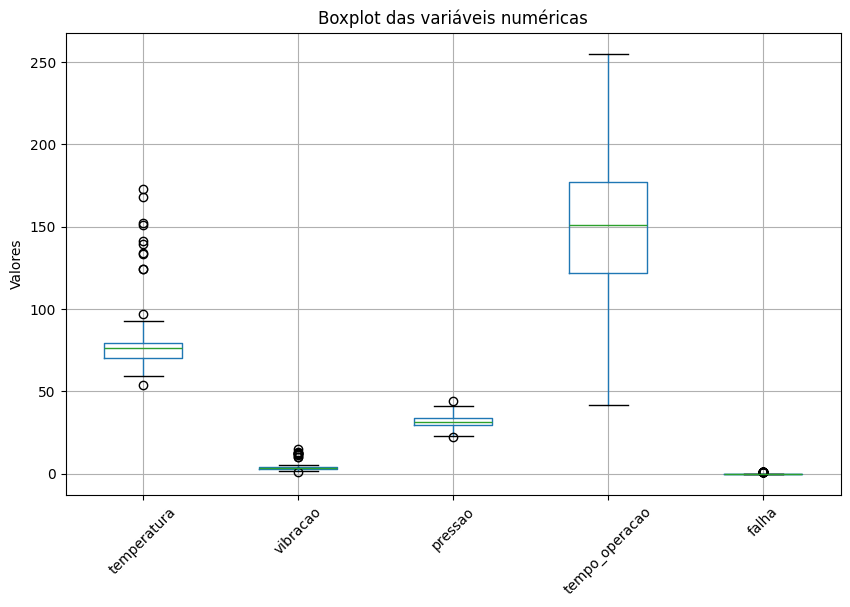

In [60]:
# Criar boxplots para observar possíveis outliers
plt.figure(figsize=(10, 6))
df_tratado.boxplot()
plt.title("Boxplot das variáveis numéricas")
plt.ylabel("Valores")
plt.xticks(rotation=45)
plt.show()


### Análise do aluno
Observe o gráfico acima e registre sua interpretação:

- Quais colunas parecem ter outliers?
- Esses outliers devem ser removidos ou apenas observados?
- Qual o impacto possível desses valores no modelo?


In [61]:
# Escreva aqui sua análise

#As colunas temperatura, vibração e pressão apresentam outliers, a decisão de remover ou apenas observar um outlier
#depende do que causou o surgimento deles e do objetivo da análise.


## 7. Separação entre variáveis de entrada e variável alvo

No Machine Learning supervisionado, separamos:
- **X**: variáveis de entrada;
- **y**: variável alvo.

Neste projeto:
- a coluna **falha** é a variável alvo;
- as demais colunas são as variáveis de entrada.


In [62]:
# Variáveis de entrada
X = df_tratado.drop("falha", axis=1)

# Variável alvo (Indique a variável alvo)
y = df_tratado["falha"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)


Formato de X: (200, 4)
Formato de y: (200,)


## 8. Divisão em treino e teste

Agora vamos dividir os dados em:
- **dados de treino**: usados para ensinar o modelo;
- **dados de teste**: usados para avaliar o modelo.

Neste exemplo, vamos usar:
- 70% para treino
- 30% para teste


In [63]:
# Dividir os dados em treino e teste (Escreva o algoritmo utilizando 70, 30. Dica: x_train, x_test, test_size=0.3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (140, 4)
X_test: (60, 4)
y_train: (140,)
y_test: (60,)


### Reflexão
Por que não devemos treinar e testar o modelo usando exatamente os mesmos dados?


In [64]:
# Escreva aqui sua resposta

#Quando o modelo é testado nos mesmos dados de treino, ele pode atingir uma acurácia de 100% simplesmente porque decorou o padrão dos dados.
#Ele apenas aprendeu a associar um dado específico ao seu respectivo rótulo.


## 9. Criação e treinamento do modelo

Agora vamos utilizar o algoritmo **Árvore de Decisão**.
Esse algoritmo cria regras de decisão a partir dos dados para classificar os exemplos.


In [65]:
# Criar o modelo
model = DecisionTreeClassifier(random_state=42,max_depth=4)

# Treinar o modelo com os dados de treino (Escreva o método)
model.fit(X_train, y_train)

print("Modelo treinado com sucesso.")


Modelo treinado com sucesso.


## 10. Realização das predições

Depois que o modelo é treinado, ele pode ser usado para prever os dados do conjunto de teste.


In [66]:
# Realizar predições no conjunto de teste (Escreva o método)
y_pred = model.predict(X_test)

# Mostrar algumas previsões
print("Primeiras previsões:", y_pred[:10])

# Mostrar os valores reais para comparação
print("Valores reais:", y_test.values[:10])


Primeiras previsões: [0 0 0 0 0 0 0 0 1 0]
Valores reais: [0 0 0 0 0 0 0 0 1 0]


## 11. Métricas do modelo

Agora vamos avaliar o desempenho do modelo com:
- **accuracy**
- **matriz de confusão**
- **classification report**


In [67]:
# Calcular a acurácia (Escreva a função que está faltando)
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia do modelo: {acc:.2f}")


Acurácia do modelo: 0.93


In [68]:
# Matriz de confusão (Escreva a função que está faltando)
matriz = confusion_matrix(y_test, y_pred)

print("Matriz de confusão:")
print(matriz)


Matriz de confusão:
[[46  1]
 [ 3 10]]


In [69]:
# Relatório de classificação (Escreva a função que está faltando)
print("Relatório de classificação:")
print(classification_report(y_test, y_pred))


Relatório de classificação:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        47
           1       0.91      0.77      0.83        13

    accuracy                           0.93        60
   macro avg       0.92      0.87      0.90        60
weighted avg       0.93      0.93      0.93        60



## 12. Visualização simples da distribuição da variável alvo

Vamos observar quantos casos normais e quantos casos de falha existem no dataset.


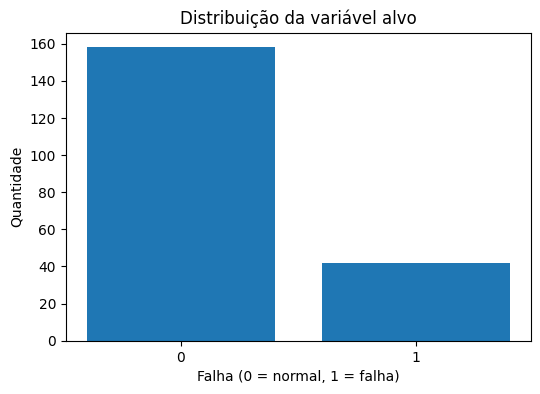

In [70]:
# Contagem da variável alvo
contagem_falha = df_tratado["falha"].value_counts()

# Gráfico de barras
plt.figure(figsize=(6, 4))
plt.bar(contagem_falha.index.astype(str), contagem_falha.values)
plt.title("Distribuição da variável alvo")
plt.xlabel("Falha (0 = normal, 1 = falha)")
plt.ylabel("Quantidade")
plt.show()


## 13. Predição com um novo exemplo

Nesta etapa, você pode testar o modelo com um exemplo manual.


In [71]:
# Exemplo de nova amostra
nova_amostra = [[82, 4.6, 36, 210]]

# Realizar predição
pred = model.predict(nova_amostra)

print("Predição do modelo:", pred[0])

if pred[0] == 0:
    print("Classificação: funcionamento normal")
else:
    print("Classificação: possível falha")


Predição do modelo: 0
Classificação: funcionamento normal


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## 14. Desafio opcional

Tente fazer ao menos uma das melhorias abaixo:

1. testar outro valor de `test_size`;
2. limitar a profundidade da árvore com `max_depth`;
3. comparar resultados antes e depois do tratamento dos dados;
4. testar remoção de outliers;
5. criar mais gráficos para explorar o dataset.


In [73]:
# Espaço livre para seus testes

#Adicionei max_depth=4 para limitar a profundidade da árvore.


## 15. Conclusão do projeto

Escreva uma conclusão curta respondendo:

- O modelo teve bom desempenho?
- Quais dificuldades foram encontradas no tratamento dos dados?
- Os outliers podem ter influenciado o resultado?
- Como esse tipo de solução pode ser útil em um ambiente industrial?


In [74]:
# Escreva aqui sua conclusão final
#O modelo apresentou uma acurácia de 93% o que demonstra um bom resultado.

# Checklist de entrega

Antes de enviar seu projeto, confirme se você realizou:

- [ ] carregamento do dataset
- [ ] análise inicial dos dados
- [ ] verificação de valores faltantes
- [ ] tratamento dos dados faltantes
- [ ] observação de outliers
- [ ] separação entre X e y
- [ ] divisão em treino e teste
- [ ] treinamento do modelo
- [ ] predição
- [ ] cálculo das métricas
- [ ] conclusão final
